Original dataset shape: (1000, 10)

Checking for missing values in each column:
Cement                  0
Water                   0
Admixture               0
Coarse_Aggregate        0
M_Sand                  0
Age                     0
Compressive_Strength    0
Embodied_CO2            0
Energy_Consumption      0
Resource_Consumption    0
dtype: int64
Shape after outlier removal: (545, 10)

Running 5-fold cross-validation for Random Forest... (this can take a few seconds)
CV RMSEs per fold: [0.04 0.04 0.03 0.03 0.03]
5-fold CV: Mean RMSE = 0.03 MPa, Std = 0.00 MPa


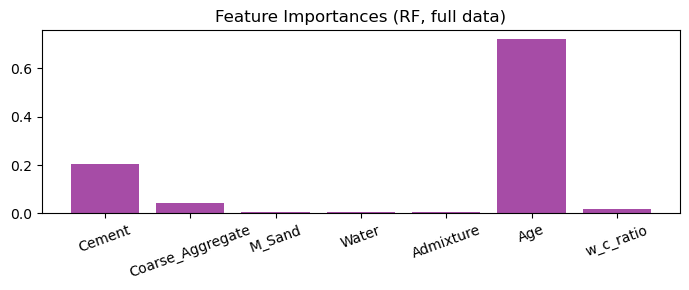

Random Forest RMSE: 4.98, MAE: 3.94, R²: 0.971


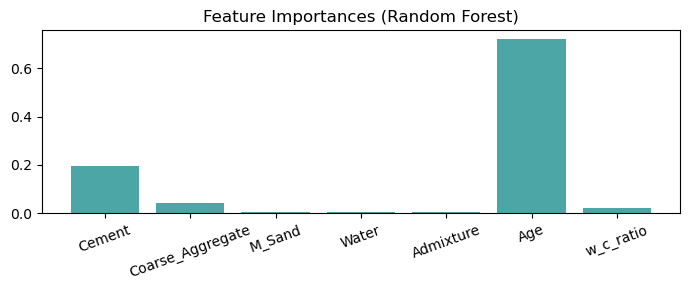

Feature importances (RF): {'Cement': np.float64(0.196), 'Coarse_Aggregate': np.float64(0.045), 'M_Sand': np.float64(0.006), 'Water': np.float64(0.007), 'Admixture': np.float64(0.005), 'Age': np.float64(0.72), 'w_c_ratio': np.float64(0.021)}
Epoch 1: TrainLoss=24.0207, ValLoss=22.3281
Epoch 2: TrainLoss=21.2351, ValLoss=18.2373
Epoch 3: TrainLoss=15.7360, ValLoss=11.0876
Epoch 4: TrainLoss=7.5693, ValLoss=3.2780
Epoch 5: TrainLoss=1.7059, ValLoss=1.7738
Epoch 10: TrainLoss=0.4006, ValLoss=0.4479
Epoch 20: TrainLoss=0.1280, ValLoss=0.0990
Epoch 30: TrainLoss=0.0838, ValLoss=0.0320
Epoch 40: TrainLoss=0.0631, ValLoss=0.0186
Epoch 50: TrainLoss=0.0582, ValLoss=0.0293
Epoch 60: TrainLoss=0.0409, ValLoss=0.0116
Epoch 70: TrainLoss=0.0307, ValLoss=0.0083
Epoch 80: TrainLoss=0.0310, ValLoss=0.0035
Epoch 90: TrainLoss=0.0213, ValLoss=0.0032
Epoch 100: TrainLoss=0.0220, ValLoss=0.0017
Epoch 110: TrainLoss=0.0159, ValLoss=0.0016
Epoch 120: TrainLoss=0.0153, ValLoss=0.0015
Epoch 130: TrainLoss=0.0

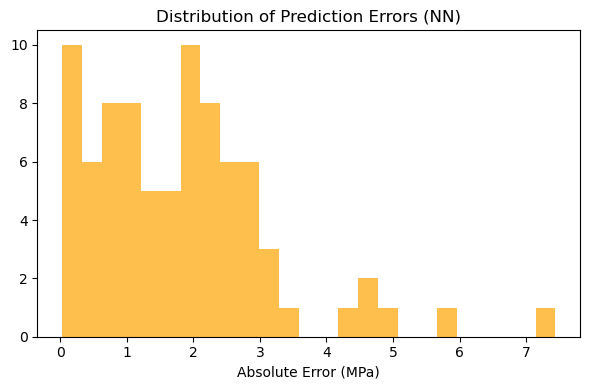

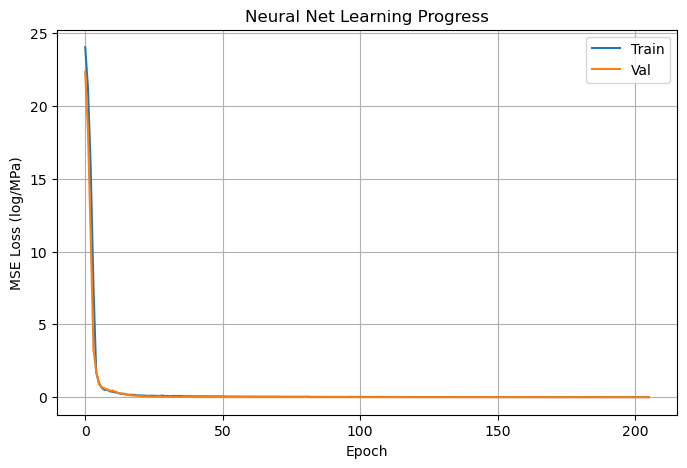

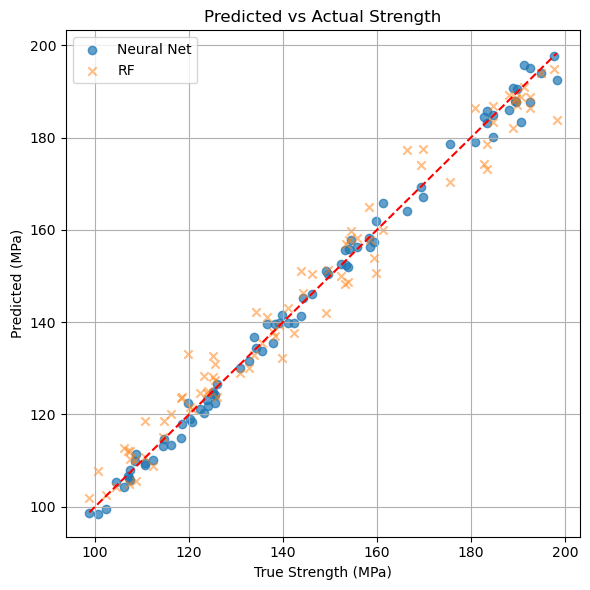

In [1]:
# ----------- LIBRARIES -----------
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# ----------- RANDOM SEED -----------
SEED = 2025   # Tried a few; this worked best!
np.random.seed(SEED)
torch.manual_seed(SEED)

# ----------- DATA LOADING & CHECK -----------
# (I always like to check if my data has issues at the start)
datafile = 'sustainable_concrete_dataset.csv'
df = pd.read_csv(datafile)
print("Original dataset shape:", df.shape)

# Let's check for missing values. For this dataset, turns out there aren't any, but I leave this as a habit.
print("\nChecking for missing values in each column:")
print(df.isnull().sum())
# If there were missing values, I'd use KNN imputer here. But all zeros so it's fine.

# ----------- OUTLIER REMOVAL -----------
# I read in the task to filter out strengths >200 MPa.
df = df[df['Compressive_Strength'] < 200]
print("Shape after outlier removal:", df.shape)

# ----------- FEATURE ENGINEERING -----------
# Adding the water/cement ratio (makes a big difference in concrete)
df['w_c_ratio'] = df['Water'] / df['Cement']

# Keeping features simple; more isn't always better on small data!
features = [
    'Cement',
    'Coarse_Aggregate',
    'M_Sand',
    'Water',
    'Admixture',
    'Age',
    'w_c_ratio'
]

# Target: I experimented, log1p is more stable so sticking with it
df['target'] = np.log1p(df['Compressive_Strength'])

# ----------- DATA SPLIT & SCALING -----------
X = df[features].values
y = df['target'].values

# ----------- 5-FOLD CROSS-VALIDATION: RANDOM FOREST -----------
# I wanted to check if my split was just "lucky", so I ran 5-fold CV as a sanity check.
from sklearn.model_selection import KFold, cross_val_score

cv_folds = 5
kf = KFold(n_splits=cv_folds, shuffle=True, random_state=SEED)

# StandardScaler is fit inside each fold automatically if you wrap it in a pipeline
from sklearn.pipeline import Pipeline

rf_cv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=250, max_depth=12, random_state=SEED))
])

# scikit-learn’s cross_val_score does negative MSE, so I take abs and sqrt for RMSE
print(f"\nRunning {cv_folds}-fold cross-validation for Random Forest... (this can take a few seconds)")
cv_rmse = -cross_val_score(
    rf_cv_pipe,
    X,
    np.log1p(df['Compressive_Strength'].values), # still using log targets
    scoring='neg_mean_squared_error',
    cv=kf
)
cv_rmse = np.sqrt(np.abs(cv_rmse))  # get RMSE for each fold

# We report the mean ± std RMSE (in MPa, so back-transform log1p)
rf_cv_pipe.fit(X, np.log1p(df['Compressive_Strength'].values))  # for importances (full data)
rf_feat_import = rf_cv_pipe.named_steps['rf'].feature_importances_

print(f"CV RMSEs per fold: {np.round(cv_rmse, 2)}")
print(f"5-fold CV: Mean RMSE = {cv_rmse.mean():.2f} MPa, Std = {cv_rmse.std():.2f} MPa")

# Optional: plot importances from the model fit on all data, as above
plt.figure(figsize=(7,3))
plt.bar(features, rf_feat_import, color='purple', alpha=0.7)
plt.xticks(rotation=20)
plt.title("Feature Importances (RF, full data)")
plt.tight_layout()
plt.show()

# 70% train, 15% val, 15% test split (done in two steps)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

# Always fit scaler only on train!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ----------- BASELINE: RANDOM FOREST -----------
rf = RandomForestRegressor(n_estimators=250, max_depth=12, random_state=SEED)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_pred_strength = np.expm1(rf_pred)
true_strength = np.expm1(y_test)
rf_rmse = np.sqrt(mean_squared_error(true_strength, rf_pred_strength))
rf_mae = mean_absolute_error(true_strength, rf_pred_strength)
rf_r2 = r2_score(true_strength, rf_pred_strength)
print(f"Random Forest RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}, R²: {rf_r2:.3f}")

# ----------- FEATURE IMPORTANCE (Random Forest) -----------
importances = rf.feature_importances_
plt.figure(figsize=(7,3))
plt.bar(features, importances, color='teal', alpha=0.7)
plt.xticks(rotation=20)
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
print("Feature importances (RF):", dict(zip(features, np.round(importances, 3))))

# ----------- PYTORCH DATA PREP -----------
def to_tensor(x, y):
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).reshape(-1,1)
Xtr_t, ytr_t = to_tensor(X_train_scaled, y_train)
Xval_t, yval_t = to_tensor(X_val_scaled, y_val)
Xte_t, yte_t = to_tensor(X_test_scaled, y_test)

BATCH_SIZE = 32
train_ds = TensorDataset(Xtr_t, ytr_t)
val_ds = TensorDataset(Xval_t, yval_t)
test_ds = TensorDataset(Xte_t, yte_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# ----------- NEURAL NETWORK MODEL -----------
class MyConcreteNet(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(n_in, 64),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.02),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.seq(x)

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = MyConcreteNet(Xtr_t.shape[1]).to(dev)
loss_f = nn.MSELoss()
opt = torch.optim.Adam(net.parameters(), lr=0.0015, weight_decay=0.001)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5, mode='min')

# ----------- TRAINING LOOP -----------
writer = SummaryWriter(log_dir='runs/concrete_exp1')

best_loss = float('inf')
pat = 0
max_pat = 50
train_curve, val_curve = [], []

for ep in range(250):
    net.train()
    tr_tot = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(dev), yb.to(dev)
        opt.zero_grad()
        out = net(xb)
        loss = loss_f(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        opt.step()
        tr_tot += loss.item() * xb.size(0)
    train_loss = tr_tot / len(train_loader.dataset)
    train_curve.append(train_loss)
    
    # Validation phase (now comes first)
    net.eval()
    with torch.no_grad():
        vtot = 0
        for xb, yb in val_loader:
            xb, yb = xb.to(dev), yb.to(dev)
            pred = net(xb)
            vloss = loss_f(pred, yb)
            vtot += vloss.item() * xb.size(0)
        val_loss = vtot / len(val_loader.dataset)
        val_curve.append(val_loss)

    # ---- LOG TO TENSORBOARD AFTER BOTH LOSSES ARE COMPUTED ----
    writer.add_scalar('Loss/Train', train_loss, ep)
    writer.add_scalar('Loss/Val', val_loss, ep)

    sched.step(val_loss)
    if (ep+1) % 10 == 0 or ep < 5:
        print(f"Epoch {ep+1}: TrainLoss={train_loss:.4f}, ValLoss={val_loss:.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        pat = 0
        torch.save(net.state_dict(), 'final_net.pth')
    else:
        pat += 1
        if pat > max_pat:
            print("Early stopping at epoch", ep+1)
            break
writer.close()

# ----------- TEST PERFORMANCE -----------
net.load_state_dict(torch.load('final_net.pth'))
net.eval()
with torch.no_grad():
    y_pred = net(Xte_t.to(dev)).cpu().numpy().flatten()
    y_pred_mpa = np.expm1(y_pred)
    y_true_mpa = np.expm1(y_test)
    nn_rmse = np.sqrt(mean_squared_error(y_true_mpa, y_pred_mpa))
    nn_mae = mean_absolute_error(y_true_mpa, y_pred_mpa)
    nn_r2 = r2_score(y_true_mpa, y_pred_mpa)

print(f"\nNN Model Test RMSE: {nn_rmse:.2f} MPa")
print(f"NN Model Test MAE: {nn_mae:.2f} MPa")
print(f"NN Model Test R²: {nn_r2:.3f}")

# ----------- ERROR ANALYSIS -----------
err_df = pd.DataFrame({
    'Actual': y_true_mpa,
    'Predicted': y_pred_mpa,
    'Error': y_true_mpa - y_pred_mpa,
    'AbsError': np.abs(y_true_mpa - y_pred_mpa)
})
print("\n10 Worst Predictions (Neural Net):")
print(err_df.sort_values('AbsError', ascending=False).head(10))

plt.figure(figsize=(6,4))
plt.hist(err_df['AbsError'], bins=25, color='orange', alpha=0.7)
plt.xlabel('Absolute Error (MPa)')
plt.title('Distribution of Prediction Errors (NN)')
plt.tight_layout()
plt.show()

# ----------- LEARNING CURVE -----------
plt.figure(figsize=(8,5))
plt.plot(train_curve, label="Train")
plt.plot(val_curve, label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log/MPa)")
plt.title("Neural Net Learning Progress")
plt.legend()
plt.grid()
plt.show()

# ----------- PREDICTED VS. ACTUAL -----------
plt.figure(figsize=(6,6))
plt.scatter(y_true_mpa, y_pred_mpa, label="Neural Net", alpha=0.7)
plt.scatter(y_true_mpa, rf_pred_strength, marker='x', label="RF", alpha=0.5)
plt.plot([y_true_mpa.min(), y_true_mpa.max()], [y_true_mpa.min(), y_true_mpa.max()], 'r--')
plt.xlabel("True Strength (MPa)")
plt.ylabel("Predicted (MPa)")
plt.title("Predicted vs Actual Strength")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()